<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/23521013_Arief_Purnama_Muharram_IF5171_DTLEM_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project #2: Bank Customer Churn Prediction
___


## Step 0: Google Drive Mounting

In [ ]:
from google.colab import drive


drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 1: Required Packages

In [ ]:
!pip install numpy
!pip install pandas
!pip install scikit-learn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


## Step 2: Import Dataset

In [ ]:
import pandas as pd


# Load dataset CSV
train_dataset = pd.read_csv('/content/drive/MyDrive/churn_train.csv')
test_dataset = pd.read_csv('/content/drive/MyDrive/churn_train.csv')

In [ ]:
# Print train dataset info
train_dataset.info()

print('\n')

# Print test dataset info
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 126 entries, x0 to y
dtypes: float64(120), int64(1), object(5)
memory usage: 96.1+ MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 126 entries, x0 to y
dtypes: float64(120), int64(1), object(5)
memory usage: 96.1+ MB


## Step 3: Dataset Exploration

### 3.1: Visualization Helper

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [ ]:
def create_countplot(data, xlabel=None, ylabel=None, title=None, horizontal=False, figsize=(7,7)):
  data = data.value_counts()
  plt.style.use('seaborn')
  plt.figure(figsize=figsize)
  if horizontal:
    sns.barplot(data.values, data.index, palette='colorblind') 
  else:
    sns.barplot(data.index, data.values, palette='colorblind')
  plt.title(title, fontdict={
      'fontsize': 20, 'fontweight': 'bold'
  })
  plt.xlabel(xlabel, fontdict={
      'fontsize': 15
  })
  plt.ylabel(ylabel, fontdict={
      'fontsize': 15
  })
  plt.tick_params(labelsize=12)
  plt.show()

In [ ]:
def create_countplot_with_hue(data, hue, xlabel=None, ylabel=None, title=None, figsize=(7,7)):
  plt.style.use('seaborn')
  plt.figure(figsize=figsize)
  sns.countplot(data, hue=hue, palette='colorblind')
  plt.title(title, fontdict={
      'fontsize': 20, 'fontweight': 'bold'
  })
  plt.xlabel(xlabel, fontdict={
      'fontsize': 15
  })
  plt.ylabel(ylabel, fontdict={
      'fontsize': 15
  })
  plt.tick_params(labelsize=12)
  plt.show()

In [ ]:
def create_distplot(data, xlabel=None, ylabel=None, title=None, bins=10, figsize=(7,7)):
  plt.style.use('seaborn')
  plt.figure(figsize=figsize)
  sns.distplot(data, bins=bins)
  plt.title(title, fontdict={
      'fontsize': 20, 'fontweight': 'bold'
  })
  plt.xlabel(xlabel, fontdict={
      'fontsize': 15
  })
  plt.ylabel(ylabel, fontdict={
      'fontsize': 15
  })
  plt.tick_params(labelsize=12)
  plt.show()

### 3.2: Display Sample Data

In [ ]:
import pandas as pd 


pd.set_option('display.max_columns', None)

train_dataset.head(3)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,x101,x102,x103,x104,x105,x106,x107,x108,x109,x110,x111,x112,x113,x114,x115,x116,x117,x118,x119,x120,x121,x122,x123,x124,y
0,0.067563,-2.172492,-1.713774,-0.146854,-0.685219,-0.933838,4.0,2.0,-4.476051,-1.472306,-1.218774,0.450158,4.069247,-8.340786,-6.042159,-19.878081,1.535456,-7.196990,-1.629518,-7.310819,-14.781728,Jun,52.0,-13.451818,3.259614,1.393315,-6.850996,1.233127,10.645972,39.437740,-7.117196,-27.698764,-1.281665,-4.945163,-0.168416,11.068075,-4.491661,-1.213428,-5.420863,-7.450657,-7.838034,21.860965,-0.611016,0.425767,16.179453,39.545280,-0.754010,11.305372,-3.798300,-0.069557,-55.922397,0.0,-1.476101,26.178133,-5.393946,74.773798,1.948247,-0.395665,-0.352281,-20.757913,-23.431641,13.751744,-26.500714,13.0,7.289281,-11.244785,4.462091,-58.953416,7.991542,-0.015627,-4.277164,19.563718,-11.892436,32.209681,-1.126540,-1.282367,-3.920134,1.898039,-5.246583,Laki-laki,2019.0,-1.606043,-134.716611,1.689934,1.007709,-5.321447,-18.112557,-7.471740,-0.762734,Jambi,-2.664888,-6.097308,61.524440,2010.0,-3.563344,-1.985570,9.0,-3.637475,7.930143,25.017788,2.432114,13.047540,32.867912,0.514885,1.0,36.329967,2.769484,-41.755648,SMP,-16.971953,-1.675642,2.937016,May,2.115196,-12.258328,-5.300138,4.607926,52.0,1.0,0.773809,0.766531,6.307142,9.074515,-2.694049,0.330964,0
1,0.099622,0.584803,-6.089758,-0.252186,-0.334912,-4.671281,4.0,2.0,-0.387076,-0.664552,-10.942626,0.614271,-18.838805,-5.618335,-1.714591,3.481345,-2.003401,-61.199568,2.759704,-1.398908,-0.258926,Jul,78.0,-6.080592,0.766630,-0.564441,0.227948,-0.407341,15.614308,54.077076,-2.079745,7.889010,5.947768,-9.353561,0.046577,-13.186784,4.717377,-4.052972,-6.192044,-0.962187,-2.279550,18.327611,-0.556392,0.147471,-34.864322,-4.474592,8.843940,NaN,4.735729,-9.321082,46.166641,0.0,0.049433,-7.505555,6.044189,-13.280132,-1.216204,-0.362896,1.242630,-4.823585,1.183948,-9.282450,19.474037,13.0,-9.803433,-49.595761,-0.587308,74.633579,8.688446,-0.382451,4.840808,-10.319307,13.229482,21.524979,-8.078291,-3.116921,-4.834912,-2.231936,0.303005,Perempuan,2018.0,1.403668,32.692514,0.154526,-4.222231,10.203383,-18.659471,5.813708,0.867246,Sumatera Barat,-11.955366,19.994792,-24.078004,2009.0,-2.744786,-3.089700,14.0,6.338206,-15.934667,-17.566671,2.297828,9.401954,-5.048393,-1.845015,0.0,-13.448378,-3.358568,24.358088,SMP,3.487433,-0.874075,-9.601688,May,2.063644,11.048471,-8.872949,15.889763,53.0,1.0,7.065852,0.994304,-0.028411,-21.472850,5.626095,1.293455,0
2,0.648421,3.881137,0.961359,0.217361,-1.471850,-0.975352,5.0,1.0,-0.850146,-4.011487,11.472485,0.569408,-11.316958,-3.618850,-2.748985,3.771034,0.922166,22.014273,-1.553619,1.023928,-7.152915,Jul,39.0,1.712338,8.139601,3.486176,0.392634,-1.508418,19.152437,-15.932574,1.246559,11.004250,-3.589043,-0.862284,-0.066652,-10.201114,4.142225,0.081982,-5.095749,-17.172271,4.384141,6.898550,0.126134,-0.190067,24.095527,-6.703214,19.618958,-7.588649,-6.265470,1.717002,27.729470,0.0,2.985710,-2.661099,-3.154688,-9.496621,1.302935,-1.473236,1.839571,10.175323,-2.325219,-7.472724,19.527319,14.0,0.992083,-4.801071,1.994551,52.444828,2.267412,0.737123,3.688356,-14.488131,8.306156,-6.662494,3.637829,-1.020663,1.968435,-2.372067,-4.881356,Perempuan,2019.0,-2.470936,29.780765,-0.621487,-0.660731,5.523607,-18.541325,9.411507,-1.197953,Sumatera Selatan,-6.314391,8.511448,-22.445845,2009.0,-6.039319,-10.848561,16.0,8.669439,3.141514,-9.576319,-3.116296,1.796533,20.722165,-0.850936,0.0,-25.670791,-4.319801,7.123384,SD,-1.413472,9.317408,6.794301,Jun,-4.120836,1.465743,-1.066457,13.770410,53.0,1.0,-8.598553,-2.958302,-12.784030,-36.855873,0.356093,1.499790,0


### 3.3: Get Correlation Analysis

In [ ]:
# Get correlation analysis

train_dataset.corr()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x80,x81,x82,x83,x84,x85,x86,x87,x88,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,x101,x102,x103,x104,x105,x106,x107,x109,x110,x111,x113,x114,x115,x116,x117,x118,x119,x120,x121,x122,x123,x124,y
x0,1.000000,-8.506891e-04,-0.001769,-0.003981,0.004158,-0.002562,-0.002733,0.002988,-0.000337,0.005547,0.004161,0.002603,-0.001500,0.005441,0.001022,-0.003352,0.002153,-0.003768,0.004547,0.002444,-0.004940,-0.002371,0.006357,0.001934,0.002599,-0.002394,0.003095,-0.001921,0.003568,-0.002960,-0.002636,-0.002585,-0.000944,-0.002429,0.002918,-0.001041,0.000535,-0.001932,-0.002639,-1.056510e-03,0.004771,-0.003021,0.000658,-0.001637,-0.001506,0.000637,-0.001708,-0.002684,-0.001391,-0.002632,0.001837,0.001247,-0.003518,0.002182,-0.000398,-0.001514,0.005906,0.000046,0.003714,0.004090,0.008487,-0.002214,0.000693,0.001127,-0.000775,-0.007625,0.002888,0.005037,5.985543e-03,0.002122,0.003769,0.000732,0.002053,-0.001007,-0.001945,0.004098,-0.002351,0.004649,0.001221,-0.003078,-0.004670,-0.002517,4.573897e-03,-0.001240,-0.002049,0.003088,0.000856,-0.005363,0.000245,-0.002420,-0.003128,-0.000904,-0.000716,-0.005966,-0.001954,-0.000508,0.002412,0.004356,-0.000644,0.000011,-0.004340,-3.658790e-03,0.002917,-0.004659,-0.000124,-0.006327,0.001762,0.002904,-0.002503,0.003126,-0.000118,-0.002329,-0.001543,-0.001810,-0.000421,0.001778,0.000240,0.002149,3.762995e-03,0.002547,-0.001644
x1,-0.000851,1.000000e+00,-0.005267,0.000171,-0.001632,0.003393,0.003063,0.005959,-0.006401,-0.003348,-0.004285,-0.005812,-0.002146,0.004970,0.000647,-0.006518,-0.001418,0.001538,-0.000577,0.005225,0.000830,0.006167,-0.004331,0.004099,0.004936,0.002082,0.002083,-0.002240,-0.002645,0.002245,0.001203,0.002343,-0.006077,-0.001438,0.006079,-0.005107,-0.000710,0.003473,-0.003009,-6.579325e-03,0.001271,-0.000882,-0.002032,0.008863,0.003387,-0.004000,0.001692,0.001385,0.002010,-0.004026,-0.000337,-0.002711,-0.001861,0.000984,0.005829,-0.006202,0.004233,-0.003904,0.000179,0.004076,0.006856,-0.000246,-0.002317,0.006202,-0.000610,0.000919,-0.004571,-0.007055,4.215252e-07,-0.001119,0.001067,0.000544,0.001773,0.001014,0.004705,-0.000460,0.000649,-0.003560,0.002522,0.004096,-0.004713,-0.000275,5.456612e-03,0.001109,-0.001887,0.000592,0.002247,-0.002134,-0.006195,0.005240,-0.000408,0.001062,-0.000846,-0.004774,0.000088,0.002845,0.004496,0.002633,-0.001796,0.002265,-0.000105,8.377136e-04,0.010078,-0.000862,-0.007760,-0.001880,0.000269,0.005251,-0.001046,-0.003914,-0.002862,0.000925,-0.001786,-0.002230,-0.000263,-0.000645,-0.006180,0.002637,-3.784495e-03,0.001868,-0.002780
x2,-0.001769,-5.267166e-03,1.000000,0.001796,-0.001360,0.000311,-0.002994,0.000408,0.004945,-0.000670,0.000627,-0.003151,-0.000877,-0.003122,-0.001035,-0.002259,0.003640,0.003794,0.002936,0.004201,0.006443,0.001946,0.000876,0.001223,-0.000661,-0.000424,0.002630,-0.001585,0.004555,0.006695,-0.002594,0.001262,-0.003794,0.000637,0.007300,-0.000299,-0.000536,0.004444,-0.001328,-4.032714e-03,-0.002046,-0.003321,0.003794,0.001307,0.001367,0.000339,0.000138,0.002262,-0.001429,-0.000749,-0.003271,-0.003841,-0.001529,0.000470,0.007457,-0.003157,0.003885,0.002882,-0.002983,-0.003492,0.006301,-0.004732,0.001800,0.009024,-0.005204,0.002008,-0.003074,0.002445,-6.908570e-04,0.006257,0.001282,0.000251,0.007579,-0.001978,-0.002736,-0.000681,-0.001040,0.008784,0.001267,-0.001887,-0.006889,0.001116,1.938412e-03,-0.002843,-0.001959,-0.006209,0.004257,0.002506,-0.000352,0.004044,0.002596,-0.004277,0.000247,-0.003067,0.000728,0.001864,-0.000934,0.001281,0.001035,0.004756,0.002114,2.630880e-03,0.001241,0.004291,-0.006461,-0.002510,-0.000930,-0.001085,0.002770,0.001791,-0.000437,-0.000236,0.002983,-0.002159,-0.003031,-0.002310,-0.003096,0.003399,-2.5959

## Step 4: Dataset Cleaning

### 4.1: Fix NaN Value

In [ ]:
import numpy as np


train_dataset = train_dataset.replace(np.nan, 0)
test_dataset = test_dataset.replace(np.nan, 0)

### 4.2: Nullability Checking

#### Check on Train Dataset

In [ ]:
# Check for train dataset nullability

train_dataset.isnull().any().any()

False

#### Check on Test Dataset

In [ ]:
# Check for test dataset nullability

test_dataset.isnull().any().any()

False

### 4.3: Duplicate Checking

#### Check on Train Dataset

In [ ]:
# Check for duplicate items on train dataset

train_dataset.duplicated().any()

False

In [ ]:
# Count duplicate items on train dataset 

len(train_dataset[train_dataset.duplicated()])

0

In [ ]:
# Show duplicate items on train dataset

train_dataset[train_dataset.duplicated()]

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,x101,x102,x103,x104,x105,x106,x107,x108,x109,x110,x111,x112,x113,x114,x115,x116,x117,x118,x119,x120,x121,x122,x123,x124,y


In [ ]:
# Remove duplicate items on train dataset

train_dataset.drop_duplicates(keep='first', inplace=True)

#### Check on Test Dataset

In [ ]:
# Check for duplicate items on test dataset

test_dataset.duplicated().any()

False

In [ ]:
# Count duplicate items on test dataset 

len(test_dataset[test_dataset.duplicated()])

0

In [ ]:
# Show duplicate items on test dataset 

test_dataset[test_dataset.duplicated()]

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,x101,x102,x103,x104,x105,x106,x107,x108,x109,x110,x111,x112,x113,x114,x115,x116,x117,x118,x119,x120,x121,x122,x123,x124,y


In [ ]:
# Remove duplicate items on test dataset 

test_dataset.drop_duplicates(keep='first', inplace=True)

### 4.4: Print Dataset Sample

In [ ]:
# Print train dataset
train_dataset.head(3)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,x101,x102,x103,x104,x105,x106,x107,x108,x109,x110,x111,x112,x113,x114,x115,x116,x117,x118,x119,x120,x121,x122,x123,x124,y
0,0.067563,-2.172492,-1.713774,-0.146854,-0.685219,-0.933838,4.0,2.0,-4.476051,-1.472306,-1.218774,0.450158,4.069247,-8.340786,-6.042159,-19.878081,1.535456,-7.196990,-1.629518,-7.310819,-14.781728,Jun,52.0,-13.451818,3.259614,1.393315,-6.850996,1.233127,10.645972,39.437740,-7.117196,-27.698764,-1.281665,-4.945163,-0.168416,11.068075,-4.491661,-1.213428,-5.420863,-7.450657,-7.838034,21.860965,-0.611016,0.425767,16.179453,39.545280,-0.754010,11.305372,-3.798300,-0.069557,-55.922397,0.0,-1.476101,26.178133,-5.393946,74.773798,1.948247,-0.395665,-0.352281,-20.757913,-23.431641,13.751744,-26.500714,13.0,7.289281,-11.244785,4.462091,-58.953416,7.991542,-0.015627,-4.277164,19.563718,-11.892436,32.209681,-1.126540,-1.282367,-3.920134,1.898039,-5.246583,Laki-laki,2019.0,-1.606043,-134.716611,1.689934,1.007709,-5.321447,-18.112557,-7.471740,-0.762734,Jambi,-2.664888,-6.097308,61.524440,2010.0,-3.563344,-1.985570,9.0,-3.637475,7.930143,25.017788,2.432114,13.047540,32.867912,0.514885,1.0,36.329967,2.769484,-41.755648,SMP,-16.971953,-1.675642,2.937016,May,2.115196,-12.258328,-5.300138,4.607926,52.0,1.0,0.773809,0.766531,6.307142,9.074515,-2.694049,0.330964,0
1,0.099622,0.584803,-6.089758,-0.252186,-0.334912,-4.671281,4.0,2.0,-0.387076,-0.664552,-10.942626,0.614271,-18.838805,-5.618335,-1.714591,3.481345,-2.003401,-61.199568,2.759704,-1.398908,-0.258926,Jul,78.0,-6.080592,0.766630,-0.564441,0.227948,-0.407341,15.614308,54.077076,-2.079745,7.889010,5.947768,-9.353561,0.046577,-13.186784,4.717377,-4.052972,-6.192044,-0.962187,-2.279550,18.327611,-0.556392,0.147471,-34.864322,-4.474592,8.843940,0.000000,4.735729,-9.321082,46.166641,0.0,0.049433,-7.505555,6.044189,-13.280132,-1.216204,-0.362896,1.242630,-4.823585,1.183948,-9.282450,19.474037,13.0,-9.803433,-49.595761,-0.587308,74.633579,8.688446,-0.382451,4.840808,-10.319307,13.229482,21.524979,-8.078291,-3.116921,-4.834912,-2.231936,0.303005,Perempuan,2018.0,1.403668,32.692514,0.154526,-4.222231,10.203383,-18.659471,5.813708,0.867246,Sumatera Barat,-11.955366,19.994792,-24.078004,2009.0,-2.744786,-3.089700,14.0,6.338206,-15.934667,-17.566671,2.297828,9.401954,-5.048393,-1.845015,0.0,-13.448378,-3.358568,24.358088,SMP,3.487433,-0.874075,-9.601688,May,2.063644,11.048471,-8.872949,15.889763,53.0,1.0,7.065852,0.994304,-0.028411,-21.472850,5.626095,1.293455,0
2,0.648421,3.881137,0.961359,0.217361,-1.471850,-0.975352,5.0,1.0,-0.850146,-4.011487,11.472485,0.569408,-11.316958,-3.618850,-2.748985,3.771034,0.922166,22.014273,-1.553619,1.023928,-7.152915,Jul,39.0,1.712338,8.139601,3.486176,0.392634,-1.508418,19.152437,-15.932574,1.246559,11.004250,-3.589043,-0.862284,-0.066652,-10.201114,4.142225,0.081982,-5.095749,-17.172271,4.384141,6.898550,0.126134,-0.190067,24.095527,-6.703214,19.618958,-7.588649,-6.265470,1.717002,27.729470,0.0,2.985710,-2.661099,-3.154688,-9.496621,1.302935,-1.473236,1.839571,10.175323,-2.325219,-7.472724,19.527319,14.0,0.992083,-4.801071,1.994551,52.444828,2.267412,0.737123,3.688356,-14.488131,8.306156,-6.662494,3.637829,-1.020663,1.968435,-2.372067,-4.881356,Perempuan,2019.0,-2.470936,29.780765,-0.621487,-0.660731,5.523607,-18.541325,9.411507,-1.197953,Sumatera Selatan,-6.314391,8.511448,-22.445845,2009.0,-6.039319,-10.848561,16.0,8.669439,3.141514,-9.576319,-3.116296,1.796533,20.722165,-0.850936,0.0,-25.670791,-4.319801,7.123384,SD,-1.413472,9.317408,6.794301,Jun,-4.120836,1.465743,-1.066457,13.770410,53.0,1.0,-8.598553,-2.958302,-12.784030,-36.855873,0.356093,1.499790

In [ ]:
# Print test dataset
test_dataset.head(3)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,x101,x102,x103,x104,x105,x106,x107,x108,x109,x110,x111,x112,x113,x114,x115,x116,x117,x118,x119,x120,x121,x122,x123,x124,y
0,0.067563,-2.172492,-1.713774,-0.146854,-0.685219,-0.933838,4.0,2.0,-4.476051,-1.472306,-1.218774,0.450158,4.069247,-8.340786,-6.042159,-19.878081,1.535456,-7.196990,-1.629518,-7.310819,-14.781728,Jun,52.0,-13.451818,3.259614,1.393315,-6.850996,1.233127,10.645972,39.437740,-7.117196,-27.698764,-1.281665,-4.945163,-0.168416,11.068075,-4.491661,-1.213428,-5.420863,-7.450657,-7.838034,21.860965,-0.611016,0.425767,16.179453,39.545280,-0.754010,11.305372,-3.798300,-0.069557,-55.922397,0.0,-1.476101,26.178133,-5.393946,74.773798,1.948247,-0.395665,-0.352281,-20.757913,-23.431641,13.751744,-26.500714,13.0,7.289281,-11.244785,4.462091,-58.953416,7.991542,-0.015627,-4.277164,19.563718,-11.892436,32.209681,-1.126540,-1.282367,-3.920134,1.898039,-5.246583,Laki-laki,2019.0,-1.606043,-134.716611,1.689934,1.007709,-5.321447,-18.112557,-7.471740,-0.762734,Jambi,-2.664888,-6.097308,61.524440,2010.0,-3.563344,-1.985570,9.0,-3.637475,7.930143,25.017788,2.432114,13.047540,32.867912,0.514885,1.0,36.329967,2.769484,-41.755648,SMP,-16.971953,-1.675642,2.937016,May,2.115196,-12.258328,-5.300138,4.607926,52.0,1.0,0.773809,0.766531,6.307142,9.074515,-2.694049,0.330964,0
1,0.099622,0.584803,-6.089758,-0.252186,-0.334912,-4.671281,4.0,2.0,-0.387076,-0.664552,-10.942626,0.614271,-18.838805,-5.618335,-1.714591,3.481345,-2.003401,-61.199568,2.759704,-1.398908,-0.258926,Jul,78.0,-6.080592,0.766630,-0.564441,0.227948,-0.407341,15.614308,54.077076,-2.079745,7.889010,5.947768,-9.353561,0.046577,-13.186784,4.717377,-4.052972,-6.192044,-0.962187,-2.279550,18.327611,-0.556392,0.147471,-34.864322,-4.474592,8.843940,0.000000,4.735729,-9.321082,46.166641,0.0,0.049433,-7.505555,6.044189,-13.280132,-1.216204,-0.362896,1.242630,-4.823585,1.183948,-9.282450,19.474037,13.0,-9.803433,-49.595761,-0.587308,74.633579,8.688446,-0.382451,4.840808,-10.319307,13.229482,21.524979,-8.078291,-3.116921,-4.834912,-2.231936,0.303005,Perempuan,2018.0,1.403668,32.692514,0.154526,-4.222231,10.203383,-18.659471,5.813708,0.867246,Sumatera Barat,-11.955366,19.994792,-24.078004,2009.0,-2.744786,-3.089700,14.0,6.338206,-15.934667,-17.566671,2.297828,9.401954,-5.048393,-1.845015,0.0,-13.448378,-3.358568,24.358088,SMP,3.487433,-0.874075,-9.601688,May,2.063644,11.048471,-8.872949,15.889763,53.0,1.0,7.065852,0.994304,-0.028411,-21.472850,5.626095,1.293455,0
2,0.648421,3.881137,0.961359,0.217361,-1.471850,-0.975352,5.0,1.0,-0.850146,-4.011487,11.472485,0.569408,-11.316958,-3.618850,-2.748985,3.771034,0.922166,22.014273,-1.553619,1.023928,-7.152915,Jul,39.0,1.712338,8.139601,3.486176,0.392634,-1.508418,19.152437,-15.932574,1.246559,11.004250,-3.589043,-0.862284,-0.066652,-10.201114,4.142225,0.081982,-5.095749,-17.172271,4.384141,6.898550,0.126134,-0.190067,24.095527,-6.703214,19.618958,-7.588649,-6.265470,1.717002,27.729470,0.0,2.985710,-2.661099,-3.154688,-9.496621,1.302935,-1.473236,1.839571,10.175323,-2.325219,-7.472724,19.527319,14.0,0.992083,-4.801071,1.994551,52.444828,2.267412,0.737123,3.688356,-14.488131,8.306156,-6.662494,3.637829,-1.020663,1.968435,-2.372067,-4.881356,Perempuan,2019.0,-2.470936,29.780765,-0.621487,-0.660731,5.523607,-18.541325,9.411507,-1.197953,Sumatera Selatan,-6.314391,8.511448,-22.445845,2009.0,-6.039319,-10.848561,16.0,8.669439,3.141514,-9.576319,-3.116296,1.796533,20.722165,-0.850936,0.0,-25.670791,-4.319801,7.123384,SD,-1.413472,9.317408,6.794301,Jun,-4.120836,1.465743,-1.066457,13.770410,53.0,1.0,-8.598553,-2.958302,-12.784030,-36.855873,0.356093,1.499790

## Step 5: Dataset Transformation

### 5.1: Transformation Helper

In [ ]:
def transform_attribute_values(dataset, attribute_name, attribute_dictionary = None): 
  '''
  Args:
    dataset               : Dataset DataFrame object
    attribute_name        : Attribute name to tansform
    attribute_dictionary  : Attribute dictionary as reference (optional)
  
  Return:
    transformed_attribute : Transformed dataset attribute DataFrame object
    dict_attribute        : Attribute dictionary used to transform the attributes
  '''

  if attribute_dictionary is None:
    attributes = list(dataset[attribute_name].unique())
    dict_attribute = {}
    for i in range(len(attributes)):
      if attributes[i] not in dict_attribute:
        dict_attribute[attributes[i]] = i + 1
  else:
    dict_attribute = attribute_dictionary
  
  transformed_attribute = dataset[attribute_name].apply(lambda x: dict_attribute[x])

  return (transformed_attribute, dict_attribute)

In [ ]:
def transform_helper(dataset, attributes, dictionary = None):
  '''
  Args:
    dataset     : Dataset DataFrame object
    attributes  : List of attributes name to transform
    dictionary  : Attribute dictionary with attribute name as its key (optional)
  
  Return:
    dataset     : Dataset DataFrame object
    used_dict   : Attribute dictionary used to transform the attributes
  '''

  used_dict = {}

  if dictionary is not None:
    used_dict = dictionary

  for attribute in attributes:
    if (used_dict.get(attribute) == None):
      dataset[attribute], used_dict[attribute] = transform_attribute_values(dataset, attribute)
    else:
      dataset[attribute], _ = transform_attribute_values(dataset, attribute, used_dict[attribute])
  
  return (dataset, used_dict)

In [ ]:
def check_untransformed_values(dataset, attributes, dictionary):
  '''
  Args:
    dataset     : Dataset DataFrame object
    attributes  : List of attributes name to check
    dictionary  : Attribute dictionary with attribute name as its key

  Return:
    True  : If any untransformed values exists
    False : If all values have been transformed
  '''

  result = False

  for attribute in attributes:
    check = dataset[attribute].isin(list(dictionary[attribute])).any()
    if check == True:
      result == check
  
  return result

### 5.2: Select Attributes to Transform

In [ ]:
# Get attributes name
attributes_need_to_transform = list(train_dataset.select_dtypes(exclude=['int', 'float']).columns)

# Print attributes name
print('Attributes need to transform:', attributes_need_to_transform)

Attributes need to transform: ['x21', 'x79', 'x89', 'x108', 'x112']


### 5.3: Transform Attributes

In [ ]:
# Transform attributes of train dataset
_, attributes_dict = transform_helper(train_dataset, attributes_need_to_transform)

# Transform attributes of test dataset
_, _ = transform_helper(test_dataset, attributes_need_to_transform, attributes_dict)

### 5.4: Check Transformed Attributes Quality

In [ ]:
# Define which attributes to check
attributes_to_check = attributes_need_to_transform

# Check for untransformed attributes
print('Untransformed attributes in train dataset:', 
      check_untransformed_values(train_dataset, attributes_to_check, attributes_dict))
print('Untransformed attributes in test dataset:', 
      check_untransformed_values(test_dataset, attributes_to_check, attributes_dict))

Untransformed attributes in train dataset: False
Untransformed attributes in test dataset: False


### 5.5: Dataset Checkup

In [ ]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 0 to 99999
Columns: 126 entries, x0 to y
dtypes: float64(120), int64(6)
memory usage: 96.9 MB


In [ ]:
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 0 to 99999
Columns: 126 entries, x0 to y
dtypes: float64(120), int64(6)
memory usage: 96.9 MB


In [ ]:
train_dataset.head(3)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,x101,x102,x103,x104,x105,x106,x107,x108,x109,x110,x111,x112,x113,x114,x115,x116,x117,x118,x119,x120,x121,x122,x123,x124,y
0,0.067563,-2.172492,-1.713774,-0.146854,-0.685219,-0.933838,4.0,2.0,-4.476051,-1.472306,-1.218774,0.450158,4.069247,-8.340786,-6.042159,-19.878081,1.535456,-7.196990,-1.629518,-7.310819,-14.781728,1,52.0,-13.451818,3.259614,1.393315,-6.850996,1.233127,10.645972,39.437740,-7.117196,-27.698764,-1.281665,-4.945163,-0.168416,11.068075,-4.491661,-1.213428,-5.420863,-7.450657,-7.838034,21.860965,-0.611016,0.425767,16.179453,39.545280,-0.754010,11.305372,-3.798300,-0.069557,-55.922397,0.0,-1.476101,26.178133,-5.393946,74.773798,1.948247,-0.395665,-0.352281,-20.757913,-23.431641,13.751744,-26.500714,13.0,7.289281,-11.244785,4.462091,-58.953416,7.991542,-0.015627,-4.277164,19.563718,-11.892436,32.209681,-1.126540,-1.282367,-3.920134,1.898039,-5.246583,1,2019.0,-1.606043,-134.716611,1.689934,1.007709,-5.321447,-18.112557,-7.471740,-0.762734,1,-2.664888,-6.097308,61.524440,2010.0,-3.563344,-1.985570,9.0,-3.637475,7.930143,25.017788,2.432114,13.047540,32.867912,0.514885,1.0,36.329967,2.769484,-41.755648,1,-16.971953,-1.675642,2.937016,1,2.115196,-12.258328,-5.300138,4.607926,52.0,1.0,0.773809,0.766531,6.307142,9.074515,-2.694049,0.330964,0
1,0.099622,0.584803,-6.089758,-0.252186,-0.334912,-4.671281,4.0,2.0,-0.387076,-0.664552,-10.942626,0.614271,-18.838805,-5.618335,-1.714591,3.481345,-2.003401,-61.199568,2.759704,-1.398908,-0.258926,2,78.0,-6.080592,0.766630,-0.564441,0.227948,-0.407341,15.614308,54.077076,-2.079745,7.889010,5.947768,-9.353561,0.046577,-13.186784,4.717377,-4.052972,-6.192044,-0.962187,-2.279550,18.327611,-0.556392,0.147471,-34.864322,-4.474592,8.843940,0.000000,4.735729,-9.321082,46.166641,0.0,0.049433,-7.505555,6.044189,-13.280132,-1.216204,-0.362896,1.242630,-4.823585,1.183948,-9.282450,19.474037,13.0,-9.803433,-49.595761,-0.587308,74.633579,8.688446,-0.382451,4.840808,-10.319307,13.229482,21.524979,-8.078291,-3.116921,-4.834912,-2.231936,0.303005,2,2018.0,1.403668,32.692514,0.154526,-4.222231,10.203383,-18.659471,5.813708,0.867246,2,-11.955366,19.994792,-24.078004,2009.0,-2.744786,-3.089700,14.0,6.338206,-15.934667,-17.566671,2.297828,9.401954,-5.048393,-1.845015,0.0,-13.448378,-3.358568,24.358088,1,3.487433,-0.874075,-9.601688,1,2.063644,11.048471,-8.872949,15.889763,53.0,1.0,7.065852,0.994304,-0.028411,-21.472850,5.626095,1.293455,0
2,0.648421,3.881137,0.961359,0.217361,-1.471850,-0.975352,5.0,1.0,-0.850146,-4.011487,11.472485,0.569408,-11.316958,-3.618850,-2.748985,3.771034,0.922166,22.014273,-1.553619,1.023928,-7.152915,2,39.0,1.712338,8.139601,3.486176,0.392634,-1.508418,19.152437,-15.932574,1.246559,11.004250,-3.589043,-0.862284,-0.066652,-10.201114,4.142225,0.081982,-5.095749,-17.172271,4.384141,6.898550,0.126134,-0.190067,24.095527,-6.703214,19.618958,-7.588649,-6.265470,1.717002,27.729470,0.0,2.985710,-2.661099,-3.154688,-9.496621,1.302935,-1.473236,1.839571,10.175323,-2.325219,-7.472724,19.527319,14.0,0.992083,-4.801071,1.994551,52.444828,2.267412,0.737123,3.688356,-14.488131,8.306156,-6.662494,3.637829,-1.020663,1.968435,-2.372067,-4.881356,2,2019.0,-2.470936,29.780765,-0.621487,-0.660731,5.523607,-18.541325,9.411507,-1.197953,3,-6.314391,8.511448,-22.445845,2009.0,-6.039319,-10.848561,16.0,8.669439,3.141514,-9.576319,-3.116296,1.796533,20.722165,-0.850936,0.0,-25.670791,-4.319801,7.123384,2,-1.413472,9.317408,6.794301,2,-4.120836,1.465743,-1.066457,13.770410,53.0,1.0,-8.598553,-2.958302,-12.784030,-36.855873,0.356093,1.499790,0


In [ ]:
test_dataset.head(3)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,x101,x102,x103,x104,x105,x106,x107,x108,x109,x110,x111,x112,x113,x114,x115,x116,x117,x118,x119,x120,x121,x122,x123,x124,y
0,0.067563,-2.172492,-1.713774,-0.146854,-0.685219,-0.933838,4.0,2.0,-4.476051,-1.472306,-1.218774,0.450158,4.069247,-8.340786,-6.042159,-19.878081,1.535456,-7.196990,-1.629518,-7.310819,-14.781728,1,52.0,-13.451818,3.259614,1.393315,-6.850996,1.233127,10.645972,39.437740,-7.117196,-27.698764,-1.281665,-4.945163,-0.168416,11.068075,-4.491661,-1.213428,-5.420863,-7.450657,-7.838034,21.860965,-0.611016,0.425767,16.179453,39.545280,-0.754010,11.305372,-3.798300,-0.069557,-55.922397,0.0,-1.476101,26.178133,-5.393946,74.773798,1.948247,-0.395665,-0.352281,-20.757913,-23.431641,13.751744,-26.500714,13.0,7.289281,-11.244785,4.462091,-58.953416,7.991542,-0.015627,-4.277164,19.563718,-11.892436,32.209681,-1.126540,-1.282367,-3.920134,1.898039,-5.246583,1,2019.0,-1.606043,-134.716611,1.689934,1.007709,-5.321447,-18.112557,-7.471740,-0.762734,1,-2.664888,-6.097308,61.524440,2010.0,-3.563344,-1.985570,9.0,-3.637475,7.930143,25.017788,2.432114,13.047540,32.867912,0.514885,1.0,36.329967,2.769484,-41.755648,1,-16.971953,-1.675642,2.937016,1,2.115196,-12.258328,-5.300138,4.607926,52.0,1.0,0.773809,0.766531,6.307142,9.074515,-2.694049,0.330964,0
1,0.099622,0.584803,-6.089758,-0.252186,-0.334912,-4.671281,4.0,2.0,-0.387076,-0.664552,-10.942626,0.614271,-18.838805,-5.618335,-1.714591,3.481345,-2.003401,-61.199568,2.759704,-1.398908,-0.258926,2,78.0,-6.080592,0.766630,-0.564441,0.227948,-0.407341,15.614308,54.077076,-2.079745,7.889010,5.947768,-9.353561,0.046577,-13.186784,4.717377,-4.052972,-6.192044,-0.962187,-2.279550,18.327611,-0.556392,0.147471,-34.864322,-4.474592,8.843940,0.000000,4.735729,-9.321082,46.166641,0.0,0.049433,-7.505555,6.044189,-13.280132,-1.216204,-0.362896,1.242630,-4.823585,1.183948,-9.282450,19.474037,13.0,-9.803433,-49.595761,-0.587308,74.633579,8.688446,-0.382451,4.840808,-10.319307,13.229482,21.524979,-8.078291,-3.116921,-4.834912,-2.231936,0.303005,2,2018.0,1.403668,32.692514,0.154526,-4.222231,10.203383,-18.659471,5.813708,0.867246,2,-11.955366,19.994792,-24.078004,2009.0,-2.744786,-3.089700,14.0,6.338206,-15.934667,-17.566671,2.297828,9.401954,-5.048393,-1.845015,0.0,-13.448378,-3.358568,24.358088,1,3.487433,-0.874075,-9.601688,1,2.063644,11.048471,-8.872949,15.889763,53.0,1.0,7.065852,0.994304,-0.028411,-21.472850,5.626095,1.293455,0
2,0.648421,3.881137,0.961359,0.217361,-1.471850,-0.975352,5.0,1.0,-0.850146,-4.011487,11.472485,0.569408,-11.316958,-3.618850,-2.748985,3.771034,0.922166,22.014273,-1.553619,1.023928,-7.152915,2,39.0,1.712338,8.139601,3.486176,0.392634,-1.508418,19.152437,-15.932574,1.246559,11.004250,-3.589043,-0.862284,-0.066652,-10.201114,4.142225,0.081982,-5.095749,-17.172271,4.384141,6.898550,0.126134,-0.190067,24.095527,-6.703214,19.618958,-7.588649,-6.265470,1.717002,27.729470,0.0,2.985710,-2.661099,-3.154688,-9.496621,1.302935,-1.473236,1.839571,10.175323,-2.325219,-7.472724,19.527319,14.0,0.992083,-4.801071,1.994551,52.444828,2.267412,0.737123,3.688356,-14.488131,8.306156,-6.662494,3.637829,-1.020663,1.968435,-2.372067,-4.881356,2,2019.0,-2.470936,29.780765,-0.621487,-0.660731,5.523607,-18.541325,9.411507,-1.197953,3,-6.314391,8.511448,-22.445845,2009.0,-6.039319,-10.848561,16.0,8.669439,3.141514,-9.576319,-3.116296,1.796533,20.722165,-0.850936,0.0,-25.670791,-4.319801,7.123384,2,-1.413472,9.317408,6.794301,2,-4.120836,1.465743,-1.066457,13.770410,53.0,1.0,-8.598553,-2.958302,-12.784030,-36.855873,0.356093,1.499790,0


## Step 6: Model Development

### 6.0: Feature Selection

In [ ]:
# The data attribute is hard to read and less meaning as the attribute have been encrypted.
# So, we try the 'divide-and-conquer' technique to select the features to be included in the analysis.
# The technique purposed is rely on the correlation matrix of the given dataset.

n_features_to_try = 21

correlation_matrix = train_dataset.corr()

temp_1 = correlation_matrix.sort_values(by=['y'])['y']
temp_2 = pd.DataFrame(temp_1.drop(['y']))
selected_column_name = list(temp_2.tail(n_features_to_try).index)

selected_column_name.append('y')

train_dataset = train_dataset[selected_column_name]
test_dataset = test_dataset[selected_column_name]

### 6.1: Create Train, Test, and Validation Dataset

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    train_dataset.drop(columns=['y']), train_dataset['y'], test_size=0.3, random_state=0
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Y_train shape:', y_train.shape)
print('Y_test shape:', y_test.shape)

X_train shape: (70000, 21)
X_test shape: (30000, 21)
Y_train shape: (70000,)
Y_test shape: (30000,)


### 6.2: Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier


dec_tree_model = DecisionTreeClassifier(random_state=0)

In [ ]:
dec_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
y_pred_dec_tree_model = dec_tree_model.predict(X_test)

### 6.3: Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier


rand_forest_model = RandomForestClassifier(random_state=0)

In [ ]:
rand_forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
y_pred_rand_forest_model = rand_forest_model.predict(X_test)

### 6.4: XGB Classifier

In [ ]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier()

In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier()

In [ ]:
y_pred_xgb_model = xgb_model.predict(X_test)

## Step 7: Model Evaluation

### 7.1: Eval Helper

In [ ]:
from sklearn import metrics


def eval_model(eval_name, y_test, y_pred):
  '''
  Args:
    eval_name : Model test name
    y_test    : Ground truth values
    y_pred    : Prediction values

  Return:
    eval_name       : Model test name
    result_accuracy_score  : Model accuracy score
    result_f1_score        : F1 accuracy score
  '''

  result_accuracy_score = metrics.accuracy_score(y_test, y_pred)
  result_precision_score = metrics.precision_score(y_test, y_pred)
  result_recall_score = metrics.recall_score(y_test, y_pred)
  result_fpr = 1 - result_recall_score
  fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
  result_auc_score = metrics.auc(fpr, tpr)
  result_f1_score = metrics.f1_score(y_test, y_pred)

  return (eval_name, result_accuracy_score, result_precision_score, 
          result_recall_score, result_fpr, result_auc_score, result_f1_score)

In [ ]:
from sklearn import metrics


def create_roc_curve(y_test, y_pred, title=None):
  fpr, tpr, _ = metrics.roc_curve(y_test.ravel(), y_pred.ravel())
  roc_auc = metrics.auc(fpr, tpr)

  plt.figure()
  lw = 1
  plt.plot(
      fpr,
      tpr,
      color="darkorange",
      lw=lw,
      label="ROC curve (area = %0.2f)" % roc_auc,
  )
  plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  if title is not None:
    plt.title(title)
  else:
    plt.title("Receiver operating characteristic example")  
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.legend(loc="lower right")
  plt.show()

### 7.2: Eval on Test Dataset

In [ ]:
import pandas as pd


eval_results = pd.DataFrame(columns=['Eval Name', 'Accuracy Score', 'Precision Score', 
                                     'Recall Score', 'FPR Score', 'AUC Score', 'F1 Score'])

# Decision tree evaluation
eval_name, accuracy_score, precision_score, recall_score, fpr, auc_score, f1_score = eval_model('Decision Tree', y_test, y_pred_dec_tree_model)
eval_results = eval_results.append(pd.DataFrame([[eval_name, accuracy_score, precision_score, recall_score, fpr, auc_score, f1_score]], 
                                                columns=['Eval Name', 'Accuracy Score', 'Precision Score', 'Recall Score', 'FPR Score', 'AUC Score', 'F1 Score']), ignore_index=True)

# Random forest evaluation
eval_name, accuracy_score, precision_score, recall_score, fpr, auc_score, f1_score = eval_model('Random Forest', y_test, y_pred_rand_forest_model)
eval_results = eval_results.append(pd.DataFrame([[eval_name, accuracy_score, precision_score, recall_score, fpr, auc_score, f1_score]], 
                                                columns=['Eval Name', 'Accuracy Score', 'Precision Score', 'Recall Score', 'FPR Score', 'AUC Score', 'F1 Score']), ignore_index=True)

# XGBoost evaluation
eval_name, accuracy_score, precision_score, recall_score, fpr, auc_score, f1_score = eval_model('XGBoost', y_test, y_pred_xgb_model)
eval_results = eval_results.append(pd.DataFrame([[eval_name, accuracy_score, precision_score, recall_score, fpr, auc_score, f1_score]], 
                                                columns=['Eval Name', 'Accuracy Score', 'Precision Score', 'Recall Score', 'FPR Score', 'AUC Score', 'F1 Score']), ignore_index=True)

eval_results

,Eval Name,Accuracy Score,Precision Score,Recall Score,FPR Score,AUC Score,F1 Score
0,Decision Tree,0.778467,0.361215,0.396819,0.603181,0.626663,0.378181
1,Random Forest,0.876533,0.901677,0.306106,0.693894,0.649641,0.457051
2,XGBoost,0.851033,0.852941,0.148046,0.851954,0.571413,0.252300


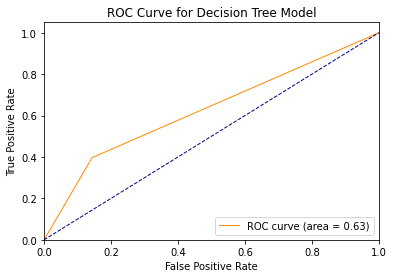

In [ ]:
create_roc_curve(y_test, y_pred_dec_tree_model, 'ROC Curve for Decision Tree Model')

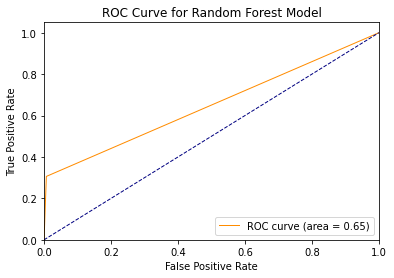

In [ ]:
create_roc_curve(y_test, y_pred_rand_forest_model, 'ROC Curve for Random Forest Model')

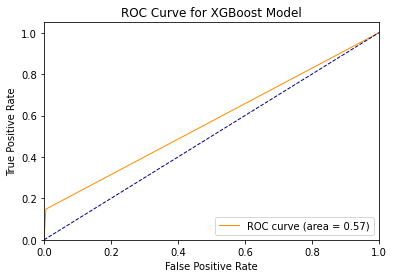

In [ ]:
create_roc_curve(y_test, y_pred_xgb_model, 'ROC Curve for XGBoost Model')

## Step 8: Save model

### 8.1: Dump Helper

In [ ]:
from joblib import dump, load


def save_model(model, name='model.joblib'):
  dump(model, name)

### 8.2: Dump Model

In [ ]:
selected_model = xgb_model
model_name = '23521013-Arief Purnama Muharram-IF5171-DTLEM-2.joblib'

save_model(selected_model, model_name)

## Step 9: Predict on 'Test' Production Dataset

### 9.1: Load Model

In [ ]:
loaded_model = load(model_name)

### 9.2: Load Dataset

In [ ]:
X_test_production = test_dataset[selected_column_name]
X_test_production = test_dataset.drop(columns=['y'])
y_test_production = test_dataset['y']

print('X_val shape:', X_test_production.shape)
print('Y_val shape:', y_test_production.shape)

X_val shape: (100000, 21)
Y_val shape: (100000,)


### 9.3: Predict Validation Set

In [ ]:
y_test_production_pred = loaded_model.predict(X_test_production)

### 9.4: Print Performance Result

In [ ]:
eval_name, accuracy_score, precision_score, recall_score, fpr, auc_score, f1_score = eval_model('churn_test.csv', y_test_production, y_test_production_pred)

print('[Performance Result]')
print('Eval name:', eval_name)
print('Accuracy score:', accuracy_score)
print('Precision score:', precision_score)
print('Recall score:', recall_score)
print('FPR score:', fpr)
print('AUC score:', auc_score)
print('F1 score:', f1_score)

[Performance Result]
Eval name: churn_test.csv
Accuracy score: 0.85207
Precision score: 0.85207
Recall score: 0.85207
FPR score: 0.85207
AUC score: 0.85207
F1 score: 0.2583103534720481


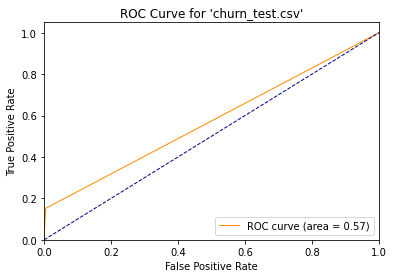

In [ ]:
create_roc_curve(y_test_production, y_test_production_pred, 'ROC Curve for \'churn_test.csv\'')

### 9.5: Save The Results

In [ ]:
import pandas as pd 


csv_name = '23521013-Arief Purnama Muharram-IF5171-DTLEM-2.csv'

y_test_production_pred = pd.Series(y_test_production_pred)

results = pd.DataFrame({'Id': range(len(y_test_production)), 'Prediction': y_test_production_pred})

results.to_csv(csv_name)